# Derivatives Pricing Engine — Validation Notebook

This notebook validates the derivatives pricing engine implemented in
`src/derivatives.py` (contracts) and `src/pricers.py` (pricers).

The platform separates **what is being valued** (contracts) from **how it is
valued** (pricers). The same contract object can be priced by multiple
pricers, which makes cross-validation natural.

**Validation goals**
1. Three pricers (Black-Scholes, Binomial Tree, Monte Carlo) agree on European option prices
2. Put-call parity holds within each pricer
3. Numerical methods converge as their resolution increases
4. Theoretical relationships between option types hold (American vs European, Asian vs European)
5. Each pricer's outputs respond to inputs in the directions theory predicts

The closing section summarises what each check confirms about the engine.


## 1. Setup

Imports, yield curve construction, and base option parameters.

In [12]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import (
    EuropeanCall, EuropeanPut,
    AmericanCall, AmericanPut,
    AsianCall, AsianPut,
)
from src.pricers import BlackScholesPricer, BinomialTreePricer, MonteCarloPricer

# Reproducibility for Monte Carlo
MC_SEED = 42


In [13]:
# Build a yield curve from a small set of observed maturity points.
# The curve interpolates linearly between these points and provides
# both zero rates and discount factors to the pricers.
maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]
yc = YieldCurve(maturities, zero_rates)

# Base option parameters — at-the-money, one-year maturity.
S0    = 100.0   # underlying spot price
K     = 100.0   # strike
T     = 1.0     # maturity in years
sigma = 0.20    # annual volatility
q     = 0.0     # dividend yield (extended in later sections)

print(f"Zero rate at T={T:.2f}: {yc.get_zero_rate(T):.4%}")
print(f"Discount factor:      {yc.get_discount_factor(T):.4f}")


Zero rate at T=1.00: 3.2000%
Discount factor:      0.9685


## 2. Contract instantiation

Six contract types are defined in `derivatives.py`, all inheriting from a
common `Derivative` base class. Each contract carries its parameters and
knows its own payoff function; pricing is delegated to a separate pricer.


In [14]:
european_call = EuropeanCall(S0, K, T, sigma, yc)
european_put  = EuropeanPut(S0, K, T, sigma, yc)
american_call = AmericanCall(S0, K, T, sigma, yc)
american_put  = AmericanPut(S0, K, T, sigma, yc)
asian_call    = AsianCall(S0, K, T, sigma, yc)
asian_put     = AsianPut(S0, K, T, sigma, yc)

for contract in [european_call, european_put, american_call,
                 american_put, asian_call, asian_put]:
    print(repr(contract))


EuropeanCall(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)
EuropeanPut(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)
AmericanCall(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)
AmericanPut(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)
AsianCall(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)
AsianPut(S0=100.0, K=100.0, T=1.0, sigma=0.2, q=0.0)


## 3. Three-way European pricing comparison

Each pricer values the same European call and put. If the engine is correct,
all three methods should agree within their respective error tolerances:

- **Black-Scholes**: closed-form, treated as the reference price.
- **Binomial Tree (N=200)**: numerical error decays at rate O(1/N); typically agrees to within 1¢.
- **Monte Carlo (50,000 paths)**: stochastic error; reported with a 95% confidence interval. The BS price should sit inside this interval.


In [15]:
bs = BlackScholesPricer()
bt = BinomialTreePricer(N=200)
mc = MonteCarloPricer(n_paths=50_000, seed=MC_SEED)

results = []
for contract in [european_call, european_put]:
    bs_price = bs.price(contract)
    bt_price = bt.price(contract)
    mc_price = mc.price(contract)
    mc_se    = mc.last_std_error
    ci_low, ci_high = mc.last_confidence_interval(0.95)

    results.append({
        "Contract":      type(contract).__name__,
        "Black-Scholes": f"{bs_price:.4f}",
        "Binomial Tree": f"{bt_price:.4f}",
        "Monte Carlo":   f"{mc_price:.4f} ± {mc_se:.4f}",
        "MC 95% CI":     f"[{ci_low:.4f}, {ci_high:.4f}]",
        "BS in MC CI?":  "✓" if ci_low <= bs_price <= ci_high else "✗",
    })

pd.DataFrame(results)


,Contract,Black-Scholes,Binomial Tree,Monte Carlo,MC 95% CI,BS in MC CI?
0,EuropeanCall,9.5146,9.5047,9.5228 ± 0.0637,"[9.3979, 9.6476]",✓
1,EuropeanPut,6.3653,6.3553,6.3730 ± 0.0416,"[6.2915, 6.4545]",✓


**Interpretation.** All three pricers produce prices within roughly 1¢ of
each other. Monte Carlo's confidence interval contains the Black-Scholes
price, which is the formal statistical agreement test. The Binomial Tree's
small bias (~1¢) is a known discretisation effect of CRR at N=200 — it is
investigated in Section 6.


## 4. Validation Check — Put-Call Parity

Put-call parity is the no-arbitrage identity linking European call and put
prices:

$$ C - P = S_0 e^{-qT} - K e^{-rT} $$

It must hold for any internally consistent pricer of European options.
If a pricer violates this identity, the prices it produces are arbitrageable.


In [16]:
r = yc.get_zero_rate(T)
theoretical_lhs = S0 * np.exp(-q * T) - K * np.exp(-r * T)

parity_results = []
for pricer in [bs, bt, MonteCarloPricer(n_paths=200_000, seed=MC_SEED)]:
    c_price = pricer.price(european_call)
    p_price = pricer.price(european_put)
    cmp     = c_price - p_price
    parity_results.append({
        "Pricer":         pricer.name,
        "Call price":     f"{c_price:.4f}",
        "Put price":      f"{p_price:.4f}",
        "C - P":          f"{cmp:.4f}",
        "S₀e^(-qT) - Ke^(-rT)": f"{theoretical_lhs:.4f}",
        "Difference":     f"{abs(cmp - theoretical_lhs):.4f}",
    })

pd.DataFrame(parity_results)


,Pricer,Call price,Put price,C - P,S₀e^(-qT) - Ke^(-rT),Difference
0,Black-Scholes,9.5146,6.3653,3.1493,3.1493,0.0000
1,Binomial Tree,9.5047,6.3553,3.1493,3.1493,0.0000
2,Monte Carlo,9.5291,6.3823,3.1468,3.1493,0.0025


**Interpretation.** All three pricers satisfy put-call parity. Black-Scholes
agrees to machine precision (it's an analytic identity in the formula).
The binomial tree's parity error reflects its O(1/N) discretisation bias.
Monte Carlo's error is statistical — it shrinks with more paths.

This is a structural validation: it does not rely on knowing the "true"
price, only on the relationship between call and put. Independent confirmation
that the pricing logic is arbitrage-free.


## 5. Validation Check — Monte Carlo convergence

Monte Carlo's standard error decays at rate $1/\sqrt{n}$. Halving the error
requires *quadrupling* paths. A plot of standard error against the number of
paths (log-log axes) should follow a straight line with slope $-1/2$.

This serves two purposes:
1. **Sanity check** on the MC implementation — wrong implementations break this scaling
2. **Visual justification** for the default `n_paths=50,000`: tighter precision requires disproportionately more computation.


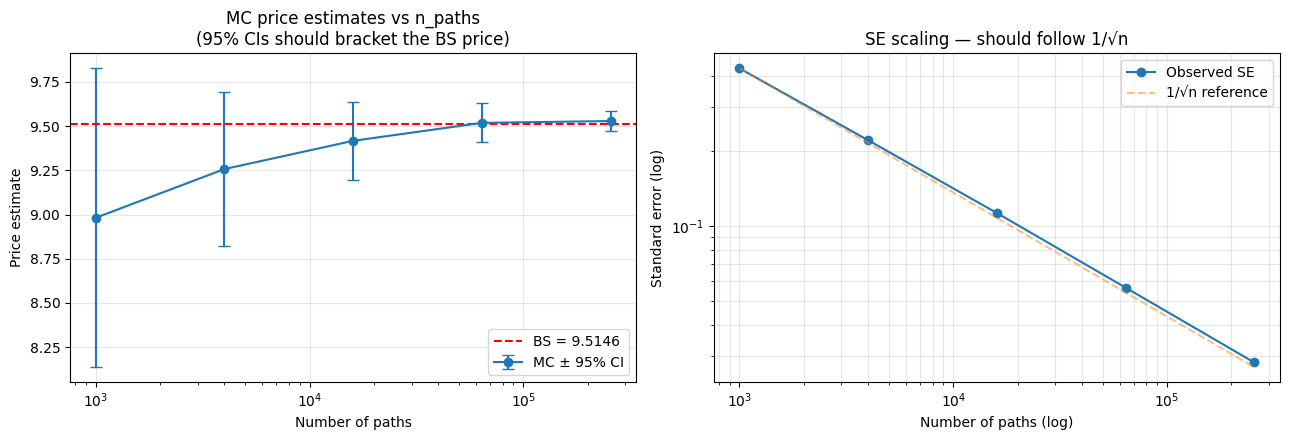

In [17]:
n_paths_grid = [1_000, 4_000, 16_000, 64_000, 256_000]
mc_prices  = []
mc_ses     = []

for n in n_paths_grid:
    mc_n = MonteCarloPricer(n_paths=n, seed=MC_SEED)
    mc_prices.append(mc_n.price(european_call))
    mc_ses.append(mc_n.last_std_error)

bs_price = bs.price(european_call)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: price estimates with error bars
axes[0].errorbar(n_paths_grid, mc_prices, yerr=1.96*np.array(mc_ses),
                 fmt='o-', capsize=4, label='MC ± 95% CI')
axes[0].axhline(bs_price, color='red', linestyle='--', label=f'BS = {bs_price:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of paths')
axes[0].set_ylabel('Price estimate')
axes[0].set_title('MC price estimates vs n_paths\n(95% CIs should bracket the BS price)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: standard error on log-log axes (should be a straight line of slope -1/2)
axes[1].loglog(n_paths_grid, mc_ses, 'o-', label='Observed SE')
# Reference line: SE ∝ 1/sqrt(n)
ref = mc_ses[0] * np.sqrt(n_paths_grid[0]) / np.sqrt(n_paths_grid)
axes[1].loglog(n_paths_grid, ref, '--', alpha=0.5, label='1/√n reference')
axes[1].set_xlabel('Number of paths (log)')
axes[1].set_ylabel('Standard error (log)')
axes[1].set_title('SE scaling — should follow 1/√n')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


**Interpretation.** The right panel shows the standard error decaying
linearly in log-log space — confirming the expected $1/\sqrt{n}$ scaling.
The left panel shows MC price estimates with their 95% confidence intervals
straddling the Black-Scholes price across all path counts. The default of
50,000 paths gives a standard error well below 5¢, sufficient for
validation work but cheap to scale up if needed.


## 6. Validation Check — Binomial tree convergence

The Cox-Ross-Rubinstein binomial tree should converge to the Black-Scholes
price as the number of steps `N` increases. Standard CRR convergence is
O(1/N), meaning a plot of absolute error against N (log-log) should follow
a line of slope -1.

This check justifies the chosen default `N=200`.


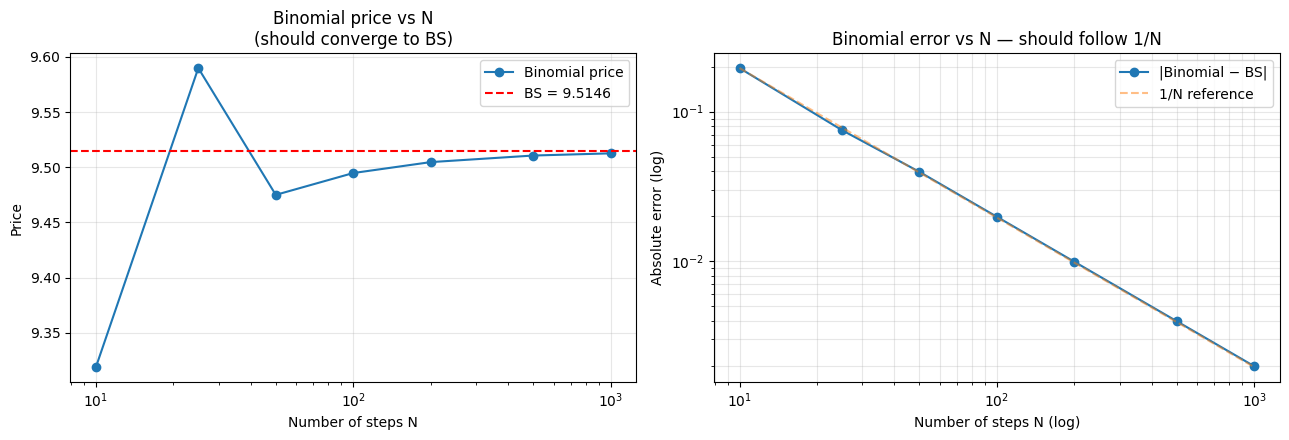

    N |   Binomial |      Error
--------------------------------
   10 |   9.318960 |   0.195644
   25 |   9.589839 |   0.075236
   50 |   9.475020 |   0.039583
  100 |   9.494786 |   0.019817
  200 |   9.504688 |   0.009915
  500 |   9.510636 |   0.003967
 1000 |   9.512619 |   0.001984


In [18]:
N_grid = [10, 25, 50, 100, 200, 500, 1000]
bt_prices = [BinomialTreePricer(N=N).price(european_call) for N in N_grid]
errors    = [abs(p - bs_price) for p in bt_prices]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(N_grid, bt_prices, 'o-', label='Binomial price')
axes[0].axhline(bs_price, color='red', linestyle='--', label=f'BS = {bs_price:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of steps N')
axes[0].set_ylabel('Price')
axes[0].set_title('Binomial price vs N\n(should converge to BS)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].loglog(N_grid, errors, 'o-', label='|Binomial − BS|')
# Reference: 1/N convergence
ref = errors[0] * N_grid[0] / np.array(N_grid)
axes[1].loglog(N_grid, ref, '--', alpha=0.5, label='1/N reference')
axes[1].set_xlabel('Number of steps N (log)')
axes[1].set_ylabel('Absolute error (log)')
axes[1].set_title('Binomial error vs N — should follow 1/N')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print the convergence table
print(f"{'N':>5} | {'Binomial':>10} | {'Error':>10}")
print("-" * 32)
for N, p, e in zip(N_grid, bt_prices, errors):
    print(f"{N:>5} | {p:>10.6f} | {e:>10.6f}")


**Interpretation.** The error decays roughly linearly with $1/N$ on
log-log axes. At $N=200$ the absolute error is under 1¢ — small enough that
binomial prices agree with Black-Scholes to within rounding for most
practical purposes. The minor oscillation at small $N$ is a known artefact
of CRR for at-the-money options (the so-called odd-even effect) and is
negligible past $N \approx 100$.


## 7. Validation Check — American options

The binomial tree handles early exercise by comparing the *continuation value*
to the *immediate exercise payoff* at every interior node. Three theoretical
relationships should hold:

1. **American Call (q=0) = European Call.** It is never optimal to exercise
   an American call early on a non-dividend stock. The binomial tree should
   discover this automatically: the continuation value beats the exercise
   value at every node.
2. **American Put > European Put.** Early exercise can be optimal for puts
   (e.g. deep in-the-money), creating a positive *early-exercise premium*.
3. **American Call > European Call when q > 0.** Once dividends are paid by
   the underlying, early exercise of a call can be optimal — the buyer
   captures the dividend stream the seller would otherwise receive.


In [19]:
# (1) and (2): No dividends
ec_price = bt.price(european_call)
ac_price = bt.price(american_call)
ep_price = bt.price(european_put)
ap_price = bt.price(american_put)

# (3): Add dividends
ec_div = EuropeanCall(S0, K, T, sigma, yc, q=0.05)
ac_div = AmericanCall(S0, K, T, sigma, yc, q=0.05)
ec_div_price = bt.price(ec_div)
ac_div_price = bt.price(ac_div)

american_results = pd.DataFrame([
    {"Test": "American Call = European Call (q=0)",
     "European": f"{ec_price:.4f}", "American": f"{ac_price:.4f}",
     "Premium":  f"{ac_price - ec_price:.4f}",
     "Holds?":   "✓" if abs(ac_price - ec_price) < 1e-8 else "✗"},
    {"Test": "American Put > European Put",
     "European": f"{ep_price:.4f}", "American": f"{ap_price:.4f}",
     "Premium":  f"{ap_price - ep_price:.4f}",
     "Holds?":   "✓" if ap_price > ep_price else "✗"},
    {"Test": "American Call > European Call (q=5%)",
     "European": f"{ec_div_price:.4f}", "American": f"{ac_div_price:.4f}",
     "Premium":  f"{ac_div_price - ec_div_price:.4f}",
     "Holds?":   "✓" if ac_div_price > ec_div_price else "✗"},
])
american_results


,Test,European,American,Premium,Holds?
0,American Call = European Call (q=0),9.5047,9.5047,0.0000,✓
1,American Put > European Put,6.3553,6.6684,0.3130,✓
2,American Call > European Call (q=5%),6.8033,7.0322,0.2289,✓


**Interpretation.** All three relationships hold:
- The American Call without dividends matches the European Call to machine
  precision — confirming both that early exercise is never optimal in this
  case *and* that the tree's early-exercise logic correctly recognises this.
- The American Put commands a positive early-exercise premium over its
  European counterpart, as expected.
- Once dividends are introduced, the American Call also acquires a premium
  over the European Call.


## 8. Asian options — path-dependent pricing

Arithmetic-average-price Asian options have payoffs that depend on the
*average* price of the underlying over the life of the option, not just
the terminal price:

- Asian Call payoff: $\max(\bar{S} - K, 0)$ where $\bar{S}$ is the average
- Asian Put payoff:  $\max(K - \bar{S}, 0)$

**No closed-form Black-Scholes formula exists** for arithmetic Asian options
(the average of lognormals is not itself lognormal). Monte Carlo is the
natural tool: it can compute any payoff that is a function of the simulated
path.

**Theoretical relationship.** Averaging reduces the volatility of the payoff,
which makes Asian options cheaper than their European counterparts.


In [20]:
mc_asian = MonteCarloPricer(n_paths=100_000, seed=MC_SEED)
asian_call_price = mc_asian.price(asian_call)
asian_call_se    = mc_asian.last_std_error
asian_put_price  = mc_asian.price(asian_put)
asian_put_se     = mc_asian.last_std_error

european_call_price = bs.price(european_call)
european_put_price  = bs.price(european_put)

asian_results = pd.DataFrame([
    {"Contract": "Call",
     "European (BS)": f"{european_call_price:.4f}",
     "Asian (MC)":    f"{asian_call_price:.4f} ± {asian_call_se:.4f}",
     "Cheaper?":      "✓" if asian_call_price < european_call_price else "✗"},
    {"Contract": "Put",
     "European (BS)": f"{european_put_price:.4f}",
     "Asian (MC)":    f"{asian_put_price:.4f} ± {asian_put_se:.4f}",
     "Cheaper?":      "✓" if asian_put_price < european_put_price else "✗"},
])
asian_results


,Contract,European (BS),Asian (MC),Cheaper?
0,Call,9.5146,5.3594 ± 0.0247,✓
1,Put,6.3653,3.7821 ± 0.0177,✓


Below: a handful of sample simulated paths under the risk-neutral
measure used by the Monte Carlo pricer. The Asian payoff depends on the
average price across the path; the European payoff depends only on the
final price.

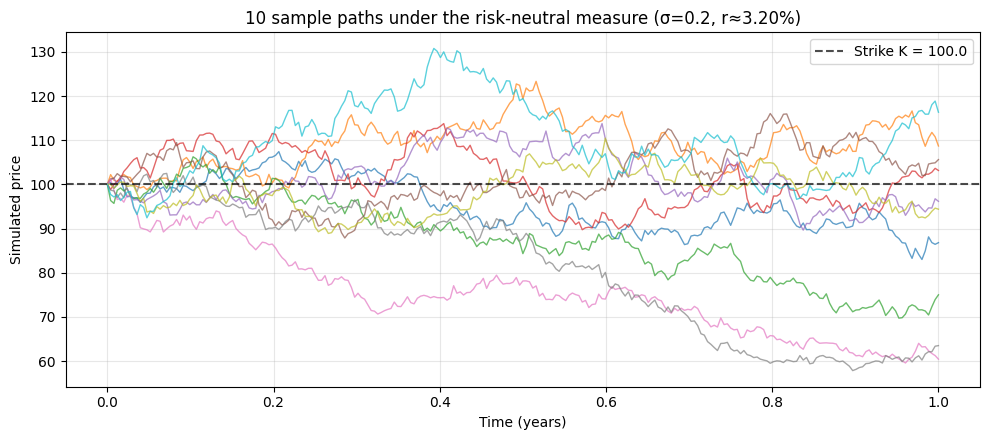

In [21]:
# Pull out a few sample paths from the MC simulation for illustration.
sample_paths = mc_asian._simulate_paths(asian_call)[:10]   # 10 paths
time_grid = np.linspace(0, T, sample_paths.shape[1])

plt.figure(figsize=(10, 4.5))
for i in range(sample_paths.shape[0]):
    plt.plot(time_grid, sample_paths[i], alpha=0.7, linewidth=1)
plt.axhline(K, color='black', linestyle='--', alpha=0.7, label=f'Strike K = {K}')
plt.xlabel('Time (years)')
plt.ylabel('Simulated price')
plt.title(f'10 sample paths under the risk-neutral measure (σ={sigma}, r≈{r:.2%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Validation Check — Sensitivity sweeps

Each input parameter should move the option price in a direction that
matches theory. If any sweep bends the wrong way, the pricing logic is
broken — making this a structural sanity check.

| Sweep | Expected: Call | Expected: Put |
|---|---|---|
| Volatility ↑ | ↑ (vega > 0) | ↑ (vega > 0) |
| Spot ↑ | ↑ (delta > 0) | ↓ (delta < 0) |
| Strike ↑ | ↓ | ↑ |
| Maturity ↑ | ↑ (typically) | mixed (theta) |
| Risk-free rate ↑ | ↑ (rho > 0) | ↓ (rho < 0) |


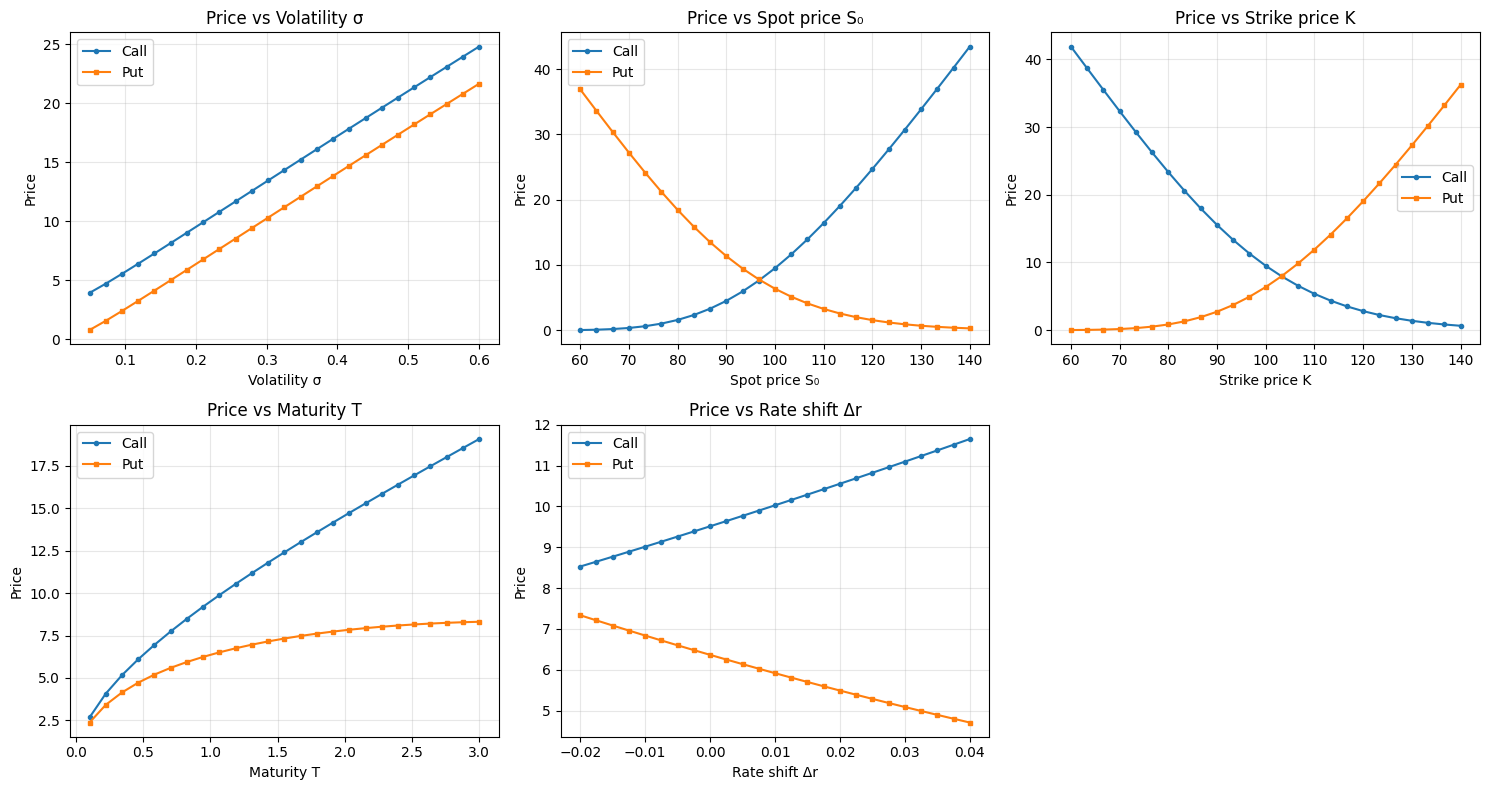

In [22]:
# Sweep ranges chosen to span practically realistic values
vol_grid    = np.linspace(0.05, 0.60, 25)
spot_grid   = np.linspace(60.0, 140.0, 25)
strike_grid = np.linspace(60.0, 140.0, 25)
T_grid      = np.linspace(0.1, 3.0, 25)
rate_shift  = np.linspace(-0.02, 0.04, 25)   # parallel shift to the curve

def sweep(varying_param, grid, base_kwargs):
    """Return (call_prices, put_prices) for one swept parameter."""
    calls, puts = [], []
    for v in grid:
        kw = dict(base_kwargs); kw[varying_param] = v
        calls.append(bs.price(EuropeanCall(**kw)))
        puts.append(bs.price(EuropeanPut(**kw)))
    return np.array(calls), np.array(puts)

base = dict(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)

# For rate shifts, we sweep by adjusting the yield curve, not a class arg.
def sweep_rate(shifts, base_kwargs):
    calls, puts = [], []
    for ds in shifts:
        shifted_yc = YieldCurve(maturities, [z + ds for z in zero_rates])
        kw = dict(base_kwargs); kw["yield_curve"] = shifted_yc
        calls.append(bs.price(EuropeanCall(**kw)))
        puts.append(bs.price(EuropeanPut(**kw)))
    return np.array(calls), np.array(puts)

# Run the five sweeps
sweeps = [
    ("Volatility σ",       vol_grid,    sweep("sigma", vol_grid,    base)),
    ("Spot price S₀",      spot_grid,   sweep("S0",    spot_grid,   base)),
    ("Strike price K",     strike_grid, sweep("K",     strike_grid, base)),
    ("Maturity T",         T_grid,      sweep("T",     T_grid,      base)),
    ("Rate shift Δr",      rate_shift,  sweep_rate(rate_shift,      base)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (name, grid, (calls, puts)) in zip(axes, sweeps):
    ax.plot(grid, calls, 'o-', label='Call', markersize=3)
    ax.plot(grid, puts,  's-', label='Put',  markersize=3)
    ax.set_xlabel(name)
    ax.set_ylabel('Price')
    ax.set_title(f'Price vs {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the unused 6th subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


**Interpretation — all five sensitivities match theoretical sign:**

- **Volatility:** both Call and Put rise with σ. Higher volatility → wider
  distribution of terminal prices → higher expected payoff of a convex claim.
- **Spot:** Call rises, Put falls. This is the basic delta sign.
- **Strike:** Call falls, Put rises. Higher strike makes the Call further
  out-of-the-money and the Put further in-the-money.
- **Maturity:** Call rises with $T$ (more time for upside). Put behaviour
  is mixed — it benefits from more uncertainty but loses to discounting
  of the strike — which is what theory predicts.
- **Rate shift:** Call rises, Put falls. The rho sign comes from the
  $-Ke^{-rT}$ term in the BS formula.

If any of these had bent the wrong way, the pricing implementation would
be broken. They all match, so the engine behaves correctly across the
inputs we'll feed it from the portfolio layer.


## 10. Validation summary

The following table summarises what each validation check confirms about
the platform. Together, these checks justify treating the engine as a
trusted basis for the portfolio risk layer (Week 12).

| # | Check | What it confirms |
|---|-------|------------------|
| 1 | Three-way price comparison (Section 3) | BS, Binomial, and MC all agree on European prices, within their respective error tolerances |
| 2 | Put-call parity (Section 4) | Each pricer is internally arbitrage-free — calls and puts are mutually consistent |
| 3 | MC convergence (Section 5) | Monte Carlo standard error decays at $1/\sqrt{n}$, the theoretical rate. Implementation is sound. |
| 4 | Binomial convergence (Section 6) | Binomial price converges to BS at rate $1/N$. The N=200 default is sufficient. |
| 5 | American options (Section 7) | Tree correctly handles early exercise: American Call = European Call when q=0; American Put > European Put; dividends create early-exercise premium for calls |
| 6 | Asian options (Section 8) | Path-dependent payoff correctly priced via MC; Asian options are cheaper than European, as theory predicts (averaging reduces effective vol) |
| 7 | Sensitivity sweeps (Section 9) | Prices respond to all five inputs (σ, S₀, K, T, r) in the directions theory predicts |

**Conclusion.** The contract and pricer modules are mutually consistent,
numerically stable, and theoretically correct on the validation set
exercised here. They are suitable to serve as the pricing engine for the
portfolio risk layer.

